# Conteo cuántico

El algoritmo de conteo cuántico estima cuántos estados marcados hay en una base de datos no estructurada de tamaño $N=2^n$.

A diferencia de Grover, que busca encontrar un estado marcado, conteo cuántico busca estimar el número de soluciones $t$. Para esto combina:

1. **Iteraciones controladas de Grover**, que codifican información de fase.
2. **QFT inversa**, que permite extraer una aproximación de esa fase.

Si $t$ es el número de estados marcados, definimos $\omega$ por

$$
\sin^2(\pi\omega)=\frac{t}{N}.
$$

Después de estimar $\omega$, estimamos $t$ usando

$$
\widetilde{t}
=
N\sin^2(\pi\widetilde{\omega}).
$$

In [38]:
%pip install qiskit numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from pathlib import Path
import os
import sys
import importlib

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display

## Cargar la carpeta y el archivo `.env`

In [40]:
PROJECT_DIR = Path.cwd()

if not (PROJECT_DIR / "quantum_algorithms.py").exists():
    candidate = PROJECT_DIR / "Quantum_algorithmos"
    if (candidate / "quantum_algorithms.py").exists():
        PROJECT_DIR = candidate
        os.chdir(PROJECT_DIR)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

env_path = PROJECT_DIR / ".env"

try:
    from dotenv import load_dotenv

    if env_path.exists():
        load_dotenv(env_path, override=True)
        print(f".env cargado desde: {env_path}")
    else:
        print(f"No se encontró .env en: {env_path}")

except ImportError:
    print("python-dotenv no está instalado. Puedes instalarlo con: pip install python-dotenv")

print(f"Carpeta de trabajo: {Path.cwd()}")
print(f"Existe quantum_algorithms.py: {(PROJECT_DIR / 'quantum_algorithms.py').exists()}")

python-dotenv no está instalado. Puedes instalarlo con: pip install python-dotenv
Carpeta de trabajo: c:\Users\juanc\github\Differential-Cryptanalysis-\Quantum_algorithmos
Existe quantum_algorithms.py: True


In [41]:
import quantum_algorithms as qa

importlib.reload(qa)

print(f"Importado desde: {qa.__file__}")

inverse_qft = qa.inverse_qft
phase_oracle = qa.phase_oracle
diffuser = qa.diffuser

print("Funciones importadas ")
print("- inverse_qft")
print("- phase_oracle")
print("- diffuser")

Importado desde: c:\Users\juanc\github\Differential-Cryptanalysis-\Quantum_algorithmos\quantum_algorithms.py
Funciones importadas 
- inverse_qft
- phase_oracle
- diffuser


## Operador de Grover para varios estados marcados

En conteo cuántico permitimos que haya varios estados marcados. La iteración de Grover es

$$
G = \Gamma O_f,
$$

donde $O_f$ es el oráculo de fase y $D$ es el difusor.

In [42]:
def validate_marked_states(marked_states: list[str]) -> int:
    """
    Verifica que la lista de estados marcados sea válida.
    """
    if not marked_states: raise ValueError("Debe haber al menos un estado marcado.")

    num_qubits = len(marked_states[0])

    if num_qubits == 0: raise ValueError("Los estados marcados no pueden ser cadenas vacías.")

    for state in marked_states:
        if len(state) != num_qubits:
            raise ValueError("Todos los estados marcados deben tener la misma longitud.")

        if any(bit not in {"0", "1"} for bit in state):
            raise ValueError("Cada estado marcado debe ser una cadena binaria.")

    return num_qubits


def grover_operator(marked_states: list[str]) -> QuantumCircuit:
    """
    Construye la iteración de Grover G = D O_f.
    """
    num_qubits = validate_marked_states(marked_states)

    operator = QuantumCircuit(num_qubits, name="G")

    oracle = phase_oracle(marked_states)
    diffusion = diffuser(num_qubits)

    operator.append(oracle.to_gate(label="O"), range(num_qubits))
    operator.append(diffusion.to_gate(label="D"), range(num_qubits))

    return operator

## Compuerta de conteo

La compuerta de conteo aplica potencias controladas de Grover. Si el primer registro está en el estado $\ket{m}$, entonces la compuerta aplica $G^m$ al segundo registro:

$$
C_{p,n}:\ket{m}_p\otimes\ket{\psi}_n
\longmapsto
\ket{m}_p\otimes G^m\ket{\psi}_n.
$$

Esto es lo que permite codificar información de fase en el primer registro.

In [43]:
def quantum_counting_circuit(
    marked_states: list[str],
    counting_qubits: int,
) -> QuantumCircuit:
    """
    Construye el circuito de conteo cuántico.

    El primer registro tiene counting_qubits.
    El segundo registro tiene search_qubits.
    """
    if counting_qubits < 1:
        raise ValueError("counting_qubits debe ser al menos 1.")

    search_qubits = validate_marked_states(marked_states)

    total_qubits = counting_qubits + search_qubits

    counting_register = list(range(counting_qubits))
    search_register = list(range(counting_qubits, total_qubits))

    circuit = QuantumCircuit(total_qubits, name="QuantumCounting")

    # Preparar |gamma>_p en el registro de conteo.
    circuit.h(counting_register)

    # Preparar |gamma>_n en el registro de búsqueda.
    circuit.h(search_register)

    grover_gate = grover_operator(marked_states).to_gate(label="G")
    controlled_grover = grover_gate.control(1)

    # Aplicar potencias controladas de Grover.
    for control_power, control in enumerate(counting_register):
        for _ in range(2 ** control_power):
            circuit.append(controlled_grover, [control] + search_register)

    # Aplicar QFT inversa al registro de conteo.
    circuit.append(
        inverse_qft(counting_qubits).to_gate(label="QFT†"),
        counting_register,
    )

    return circuit

## Estimación del número de soluciones

Si al medir el primer registro obtenemos $\widetilde{\ell}$, estimamos la fase por

$$
\widetilde{\omega}
=
\frac{\widetilde{\ell}}{2^p}.
$$

Como las fases $\omega$ y $1-\omega$ producen el mismo valor de $t$, si $\widetilde{\omega}>1/2$ usamos $1-\widetilde{\omega}$.

Finalmente calculamos

$$
\widetilde{t}
=
N\sin^2(\pi\widetilde{\omega}).
$$

In [44]:
def estimate_marked_items(
    measured_value: int,
    counting_qubits: int,
    search_qubits: int,
) -> tuple[float, float]:
    """
    Estima la fase omega y el número de estados marcados.
    """
    if counting_qubits < 1:
        raise ValueError("counting_qubits debe ser al menos 1.")

    if search_qubits < 1:
        raise ValueError("search_qubits debe ser al menos 1.")

    max_value = 2 ** counting_qubits

    if not 0 <= measured_value < max_value:
        raise ValueError(f"measured_value debe estar entre 0 y {max_value - 1}.")

    phase = measured_value / max_value

    # Corrección omega <-> 1 - omega.
    if phase > 0.5:
        phase = 1 - phase

    estimated_marked = (2 ** search_qubits) * (np.sin(np.pi * phase) ** 2)

    return phase, estimated_marked


def top_counting_results(
    probabilities: np.ndarray,
    counting_qubits: int,
    search_qubits: int,
    top_k: int = 6,
    min_probability: float = 1e-10,
) -> list[dict[str, float | str | int]]:
    """
    Devuelve los resultados más probables del registro de conteo.
    """
    top_values = np.argsort(probabilities)[::-1][:top_k]
    results = []

    for measured_value in top_values:
        probability = float(probabilities[measured_value])

        if probability < min_probability:
            continue

        bitstring = format(measured_value, f"0{counting_qubits}b")
        phase, estimated_marked = estimate_marked_items(
            measured_value,
            counting_qubits,
            search_qubits,
        )

        results.append(
            {
                "measured_value": int(measured_value),
                "bits": bitstring,
                "phase": float(phase),
                "probability": probability,
                "estimated_marked": float(estimated_marked),
            }
        )

    return results

## Ejemplo: dos estados marcados en dos qubits

Tomamos una base de datos de tamaño $N=4$, correspondiente a dos qubits. Marcamos dos estados:

$$
A=\{\ket{01},\ket{11}\}.
$$

Por tanto, el número real de soluciones es $t=2$.

In [45]:
marked_states = ["01", "11"]
counting_qubits = 4
search_qubits = len(marked_states[0])

real_marked = len(marked_states)
total_items = 2 ** search_qubits

print(f"Estados marcados: {marked_states}")
print(f"t real = {real_marked}")
print(f"N = {total_items}")
print(f"Qubits de conteo = {counting_qubits}")
print(f"Qubits de búsqueda = {search_qubits}")

Estados marcados: ['01', '11']
t real = 2
N = 4
Qubits de conteo = 4
Qubits de búsqueda = 2


In [46]:
marked_states = ["0100", "1100"]
counting_qubits = 4
search_qubits = len(marked_states[0])

real_marked = len(marked_states)
total_items = 2 ** search_qubits

print(f"Estados marcados: {marked_states}")
print(f"t real = {real_marked}")
print(f"N = {total_items}")
print(f"Qubits de conteo = {counting_qubits}")
print(f"Qubits de búsqueda = {search_qubits}")

Estados marcados: ['0100', '1100']
t real = 2
N = 16
Qubits de conteo = 4
Qubits de búsqueda = 4


## Circuito de conteo cuántico

Construimos el circuito completo. El primer registro almacena la información de fase y el segundo registro corresponde al espacio de búsqueda.

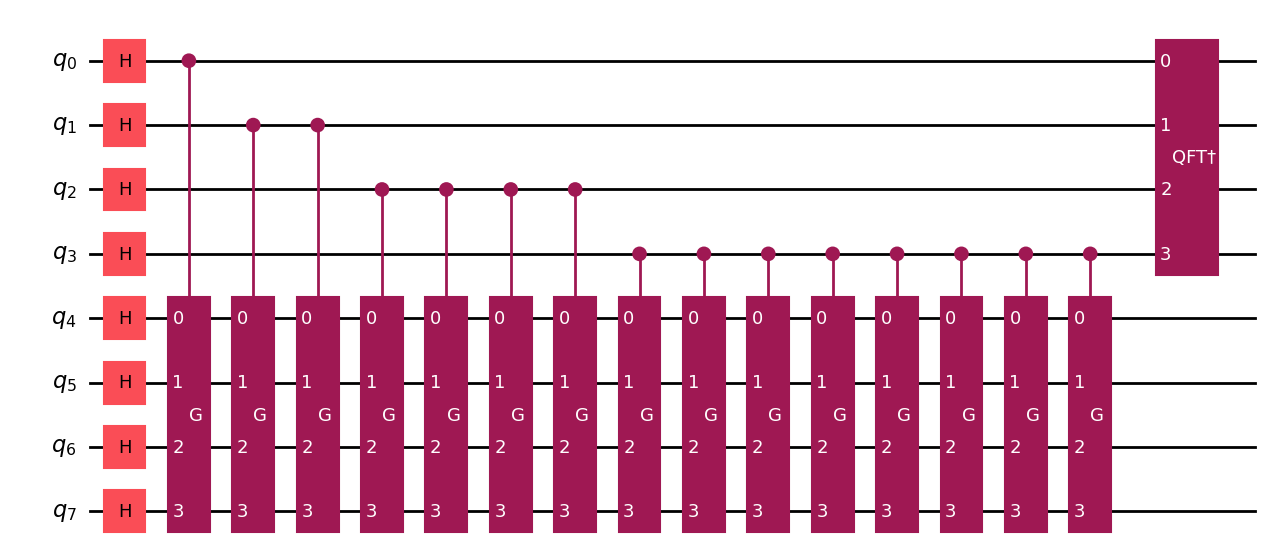

In [47]:
circuit = quantum_counting_circuit(marked_states, counting_qubits)

display(circuit.draw("mpl", fold=-1))

## Simulación

Simulamos el circuito usando `Statevector`. Luego miramos las probabilidades del primer registro, que es el registro de conteo.

In [48]:
state = Statevector.from_instruction(circuit)

counting_register = list(range(counting_qubits))
phase_probabilities = state.probabilities(qargs=counting_register)

results = top_counting_results(
    probabilities=phase_probabilities,
    counting_qubits=counting_qubits,
    search_qubits=search_qubits,
    top_k=8,
)

print(f"Estados marcados reales: {real_marked} de {total_items}")
print("\nResultados de fase más probables:")

for result in results:
    print(
        f"bits={result['bits']}, "
        f"valor={result['measured_value']}, "
        f"fase={result['phase']:.4f}, "
        f"probabilidad={result['probability']:.4f}, "
        f"t_estimado={result['estimated_marked']:.4f}"
    )

best_estimate = results[0]["estimated_marked"]

print(f"\nMejor estimación: {best_estimate:.4f}")
print(f"Estimación redondeada: {round(best_estimate)}")
print(f"Valor real: {real_marked}")

assert round(best_estimate) == real_marked

Estados marcados reales: 2 de 16

Resultados de fase más probables:
bits=1110, valor=14, fase=0.1250, probabilidad=0.4606, t_estimado=2.3431
bits=0010, valor=2, fase=0.1250, probabilidad=0.4606, t_estimado=2.3431
bits=1111, valor=15, fase=0.0625, probabilidad=0.0183, t_estimado=0.6090
bits=0001, valor=1, fase=0.0625, probabilidad=0.0183, t_estimado=0.6090
bits=1101, valor=13, fase=0.1875, probabilidad=0.0095, t_estimado=4.9385
bits=0011, valor=3, fase=0.1875, probabilidad=0.0095, t_estimado=4.9385
bits=0000, valor=0, fase=0.0000, probabilidad=0.0072, t_estimado=0.0000
bits=1100, valor=12, fase=0.2500, probabilidad=0.0032, t_estimado=8.0000

Mejor estimación: 2.3431
Estimación redondeada: 2
Valor real: 2


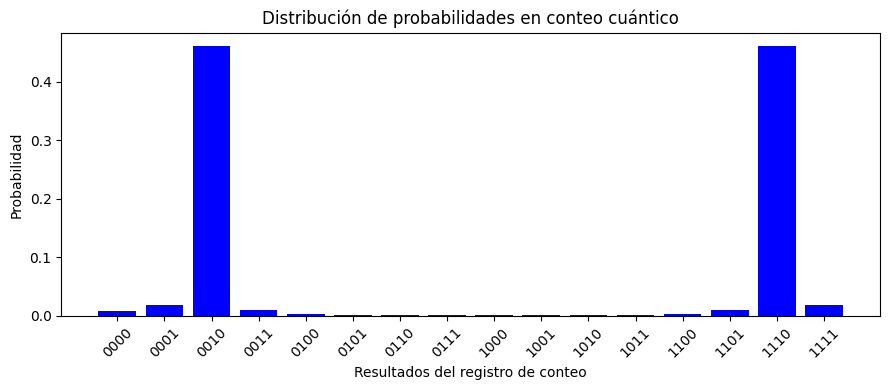

In [49]:
bitstrings = [
    format(value, f"0{counting_qubits}b")
    for value in range(2 ** counting_qubits)
]

frecuencias = phase_probabilities

plt.figure(figsize=(9, 4))
plt.bar(bitstrings, frecuencias, color="blue")
plt.xlabel("Resultados del registro de conteo")
plt.ylabel("Probabilidad")
plt.title("Distribución de probabilidades en conteo cuántico")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Segundo ejemplo

Ahora usamos una base de datos de tamaño \(N=8\), correspondiente a tres qubits, y marcamos dos estados.

In [50]:
marked_states = ["001", "111"]
counting_qubits = 5
search_qubits = len(marked_states[0])

real_marked = len(marked_states)
total_items = 2 ** search_qubits

circuit = quantum_counting_circuit(marked_states, counting_qubits)
state = Statevector.from_instruction(circuit)

phase_probabilities = state.probabilities(qargs=list(range(counting_qubits)))

results = top_counting_results(
    probabilities=phase_probabilities,
    counting_qubits=counting_qubits,
    search_qubits=search_qubits,
    top_k=8,
)

print(f"Estados marcados: {marked_states}")
print(f"Estados marcados reales: {real_marked} de {total_items}")
print("\nResultados de fase más probables:")

for result in results:
    print(
        f"bits={result['bits']}, "
        f"valor={result['measured_value']}, "
        f"fase={result['phase']:.4f}, "
        f"probabilidad={result['probability']:.4f}, "
        f"t_estimado={result['estimated_marked']:.4f}"
    )

best_estimate = results[0]["estimated_marked"]

print(f"\nMejor estimación: {best_estimate:.4f}")
print(f"Estimación redondeada: {round(best_estimate)}")
print(f"Valor real: {real_marked}")

assert round(best_estimate) == real_marked

Estados marcados: ['001', '111']
Estados marcados reales: 2 de 8

Resultados de fase más probables:
bits=00101, valor=5, fase=0.1562, probabilidad=0.3426, t_estimado=1.7777
bits=11011, valor=27, fase=0.1562, probabilidad=0.3426, t_estimado=1.7777
bits=11010, valor=26, fase=0.1875, probabilidad=0.0861, t_estimado=2.4693
bits=00110, valor=6, fase=0.1875, probabilidad=0.0861, t_estimado=2.4693
bits=00100, valor=4, fase=0.1250, probabilidad=0.0221, t_estimado=1.1716
bits=11100, valor=28, fase=0.1250, probabilidad=0.0221, t_estimado=1.1716
bits=00111, valor=7, fase=0.2188, probabilidad=0.0142, t_estimado=3.2196
bits=11001, valor=25, fase=0.2188, probabilidad=0.0142, t_estimado=3.2196

Mejor estimación: 1.7777
Estimación redondeada: 2
Valor real: 2


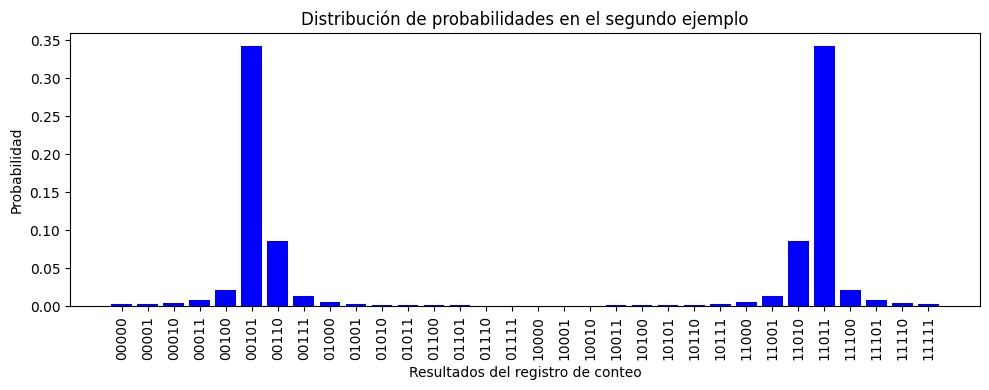

In [51]:
bitstrings = [
    format(value, f"0{counting_qubits}b")
    for value in range(2 ** counting_qubits)
]

frecuencias = phase_probabilities

plt.figure(figsize=(10, 4))
plt.bar(bitstrings, frecuencias, color="blue")
plt.xlabel("Resultados del registro de conteo")
plt.ylabel("Probabilidad")
plt.title("Distribución de probabilidades en el segundo ejemplo")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Eleccion experimental de `counting_qubits`

Aumentar el numero de qubits de conteo mejora la resolucion de fase, pero tambien aumenta el costo. Con `p` qubits de conteo, el circuito aplica

$$
1 + 2 + \cdots + 2^{p-1} = 2^p - 1
$$

iteraciones controladas de Grover. Para comparar distintos valores de `p` se usan tres metricas:

- **Probabilidad de acierto:** probabilidad total de obtener una estimacion que, al redondear, coincide con el numero real de estados marcados.
- **Error absoluto medio:** error promedio ponderado por la distribucion cuantica.
- **Costo:** numero de iteraciones controladas de Grover, igual a $2^p-1$.

La probabilidad de acierto usa el valor real solamente para evaluar ejemplos pequenos; en un problema real ese valor es precisamente el desconocido.

In [52]:
def formula_counting_qubits(search_qubits: int) -> int:
    """Calcula p usando la formula propuesta, con logaritmo en base 2."""
    if search_qubits < 1:
        raise ValueError("search_qubits debe ser al menos 1.")

    return (
        int(np.ceil(search_qubits / 2))
        + 1
        + int(np.ceil(np.log2(2 + 1 / 1.8)))
    )


def evaluate_counting_qubits(
    marked_states: list[str],
    candidates: list[int] | range,
) -> list[dict[str, float | int]]:
    """Simula cada candidato y calcula precision y costo."""
    search_qubits = validate_marked_states(marked_states)
    real_marked = len(marked_states)
    evaluations = []

    for counting_qubits in sorted(set(candidates)):
        if counting_qubits < 1:
            continue

        circuit = quantum_counting_circuit(marked_states, counting_qubits)
        state = Statevector.from_instruction(circuit)
        probabilities = state.probabilities(qargs=list(range(counting_qubits)))

        estimates = np.array(
            [
                estimate_marked_items(value, counting_qubits, search_qubits)[1]
                for value in range(2 ** counting_qubits)
            ]
        )
        rounded_estimates = np.rint(estimates).astype(int)
        peak_value = int(np.argmax(probabilities))

        evaluations.append(
            {
                "counting_qubits": counting_qubits,
                "total_qubits": counting_qubits + search_qubits,
                "grover_calls": (2 ** counting_qubits) - 1,
                "peak_estimate": float(estimates[peak_value]),
                "peak_error": float(abs(estimates[peak_value] - real_marked)),
                "mean_absolute_error": float(
                    np.dot(probabilities, np.abs(estimates - real_marked))
                ),
                "success_probability": float(
                    probabilities[rounded_estimates == real_marked].sum()
                ),
            }
        )

    return evaluations


def print_counting_qubits_table(evaluations: list[dict[str, float | int]]) -> None:
    print(" p | qubits | llamadas G | estimacion pico | error medio | P(acierto)")
    print("---|--------|------------|-----------------|-------------|-----------")

    for row in evaluations:
        print(
            f"{row['counting_qubits']:2d} | "
            f"{row['total_qubits']:6d} | "
            f"{row['grover_calls']:10d} | "
            f"{row['peak_estimate']:15.4f} | "
            f"{row['mean_absolute_error']:11.4f} | "
            f"{row['success_probability']:9.4f}"
        )


def choose_counting_qubits(
    evaluations: list[dict[str, float | int]],
    minimum_success_probability: float = 0.85,
) -> dict[str, float | int]:
    """Elige el menor p que supera el umbral; si ninguno lo logra, minimiza el error."""
    acceptable = [
        row
        for row in evaluations
        if row["success_probability"] >= minimum_success_probability
    ]

    if acceptable:
        return min(acceptable, key=lambda row: row["counting_qubits"])

    return min(
        evaluations,
        key=lambda row: (row["mean_absolute_error"], row["grover_calls"]),
    )

### Comparacion alrededor de la formula

Para el ejemplo con tres qubits de busqueda se prueban valores cercanos al producido por

$$
p = \left\lceil\frac{n}{2}\right\rceil + 1 + \left\lceil\log_2\left(2 + \frac{1}{2 \varepsilon}\right)\right\rceil,
\qquad
\varepsilon = 0.9
$$

Se usa un umbral de probabilidad de acierto de `0.85`. Este umbral puede cambiarse segun la precision y el costo aceptables.

search_qubits = 3
counting_qubits segun la formula = 5

 p | qubits | llamadas G | estimacion pico | error medio | P(acierto)
---|--------|------------|-----------------|-------------|-----------
 3 |      6 |          7 |          1.1716 |      1.3580 |    0.0000
 4 |      7 |         15 |          2.4693 |      0.8335 |    0.6885
 5 |      8 |         31 |          1.7777 |      0.4854 |    0.8573
 6 |      9 |         63 |          2.1144 |      0.2792 |    0.8985

Eleccion recomendada para este ejemplo: p=5 con P(acierto)=0.8573 y 31 llamadas controladas a G.


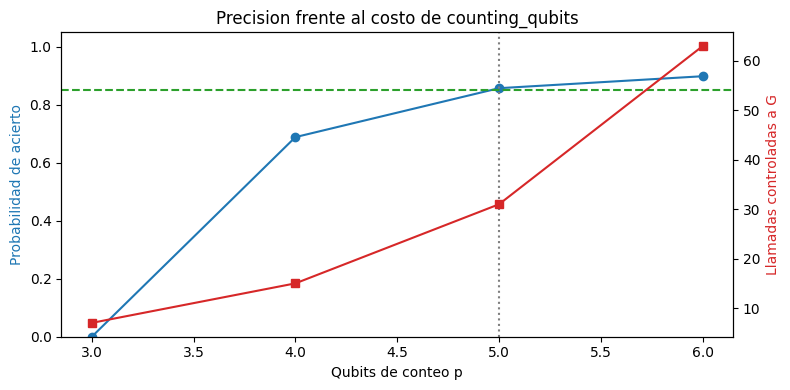

In [53]:
comparison_marked_states = ["001", "111"]
comparison_search_qubits = len(comparison_marked_states[0])
formula_p = formula_counting_qubits(comparison_search_qubits)
candidate_values = range(max(1, formula_p - 2), formula_p + 2)
success_threshold = 0.85

comparison = evaluate_counting_qubits(
    marked_states=comparison_marked_states,
    candidates=candidate_values,
)

print(f"search_qubits = {comparison_search_qubits}")
print(f"counting_qubits segun la formula = {formula_p}\n")
print_counting_qubits_table(comparison)

selected = choose_counting_qubits(
    comparison,
    minimum_success_probability=success_threshold,
)

print(
    f"\nEleccion recomendada para este ejemplo: p={selected['counting_qubits']} "
    f"con P(acierto)={selected['success_probability']:.4f} y "
    f"{selected['grover_calls']} llamadas controladas a G."
)

p_values = [row["counting_qubits"] for row in comparison]
success_values = [row["success_probability"] for row in comparison]
cost_values = [row["grover_calls"] for row in comparison]

fig, probability_axis = plt.subplots(figsize=(8, 4))
probability_axis.plot(p_values, success_values, marker="o", color="tab:blue")
probability_axis.axhline(success_threshold, color="tab:green", linestyle="--")
probability_axis.axvline(formula_p, color="tab:gray", linestyle=":")
probability_axis.set_xlabel("Qubits de conteo p")
probability_axis.set_ylabel("Probabilidad de acierto", color="tab:blue")
probability_axis.set_ylim(0, 1.05)

cost_axis = probability_axis.twinx()
cost_axis.plot(p_values, cost_values, marker="s", color="tab:red")
cost_axis.set_ylabel("Llamadas controladas a G", color="tab:red")

plt.title("Precision frente al costo de counting_qubits")
fig.tight_layout()
plt.show()

### Pruebas usando directamente la formula

La siguiente prueba aplica la formula a espacios de busqueda de 2, 3 y 4 qubits. El logaritmo se toma en base 2 porque el tamano del registro y la resolucion de fase crecen en potencias de dos.

In [54]:
formula_test_cases = [
    ["01"],
    ["001", "111"],
    ["0001", "1111"],
]

print(" n | M real | p formula | llamadas G | estimacion pico | error medio | P(acierto)")
print("---|--------|-----------|------------|-----------------|-------------|-----------")

formula_evaluations = []

for test_marked_states in formula_test_cases:
    test_search_qubits = len(test_marked_states[0])
    test_counting_qubits = formula_counting_qubits(test_search_qubits)
    evaluation = evaluate_counting_qubits(
        marked_states=test_marked_states,
        candidates=[test_counting_qubits],
    )[0]
    formula_evaluations.append(evaluation)

    print(
        f"{test_search_qubits:2d} | "
        f"{len(test_marked_states):6d} | "
        f"{test_counting_qubits:9d} | "
        f"{evaluation['grover_calls']:10d} | "
        f"{evaluation['peak_estimate']:15.4f} | "
        f"{evaluation['mean_absolute_error']:11.4f} | "
        f"{evaluation['success_probability']:9.4f}"
    )

assert [row["counting_qubits"] for row in formula_evaluations] == [4, 5, 5]

 n | M real | p formula | llamadas G | estimacion pico | error medio | P(acierto)
---|--------|-----------|------------|-----------------|-------------|-----------
 2 |      1 |         4 |         15 |          1.2346 |      0.4168 |    0.8652
 3 |      2 |         5 |         31 |          1.7777 |      0.4854 |    0.8573
 4 |      2 |         5 |         31 |          2.3431 |      0.7731 |    0.7085
